<a href="https://colab.research.google.com/github/vstimpson/scientific-computing-projects/blob/main/Copy_of_IA_SciComp_Session_3_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NST IA Scientific Computing Session 3: Curve Fitting

The third session of the course focusses on **curve fitting** techniques. Curve fitting is a very important tool in science and is, for example, often used to extract important parameters from a set of experimental data or a simulation.

You should work through this Notebook, then submit the final figure that you generate as your Work for Credit for this week, as described on the Session 3 Moodle page.  If you have time left, there is an Additional Notebook which covers some more advanced topics.

We actively encourage you to work with your colleagues and discuss the material - however your submission must be your own work. If you get stuck or don’t understand something, ask the demonstrators for help rather than spending a long time on your own.


# First Steps for Curve Fitting

In general, the aim of curve fitting is to work out the form of a function that ‘best fits’ a set of data. We usually want to fit a particular function (such as a polynomial) that involves some free parameters (i.e. the polynomial coefficients) and work out the parameters that make that function (which is sometimes referred to as a ‘model’) ‘best fit’ the data.

\

**Creating Some Data to Fit**

In this session, we are going to start by fitting a quadratic function to a set of data. We will generate some data that we know varies in a particular way, so the fitting process should work very well and we can check that it has run correctly.  You may need to refer to your Notebooks from Sessions 1 and 2, to remind yourself of some of the commands needed.

\

**Work through the following steps in the empty code cell below:**

1. Create a NumPy array, `xdata`, which contains numbers from -10 to 10 in steps of 2. The resulting array should contain 11 elements.

2. Use `xdata` to create another column vector, `ydata`, which encodes the function $y = 2x^2 + 3x + 1$

3. Plot `ydata` against `xdata` as a series of individual points, and make sure that it looks like a quadratic function, as you would expect.

In [ ]:
# This code cell is empty for you to complete the above tasks in it

import numpy as np

xdata=np.arange(-10,11,2)

ydata=2*xdata**2+3*xdata+1

print(xdata)
print(ydata)








[-10  -8  -6  -4  -2   0   2   4   6   8  10]
[171 105  55  21   3   1  15  45  91 153 231]


Now imagine that we didn’t know the coefficients of the quadratic and that we just had the data points. We want to guess a function, written in term of some parameters, then try and work out what the optimised parameters are.

In this case, starting with the general quadratic formula,

$y = ax^2 + bx + c$

would be a good idea.  We then want to use Scientific Python to working out the optimised values of $a$, $b$ and $c$ for us.

\


**Creating functions in Python**

In order to for Python to curve fit a function for us, we first need to be able to define a generalised version of that function.

Python functions are defined with the following general syntax:
```
def function_name(parameters):
  statements
  return value
```
Several points are very important to remember:

* After the `def` line, all the following lines in the function definition must be indented by exactly the same number of spaces. Python uses the indents to distinguish when the function definition finishes.
* `parameters` is a comma separated list of arguments that the function needs to use (although we can also define functions that do not need any arguments).
* You can include as many statements (lines of calculation) as you need, in order to encode the function.
* The final `return` command gives the value that is returned when you call the function.
* Don't forget the colon at the end of the `def` line!

The following code cell shows some examples of function definitions, and of using functions. **Try running the cell yourself** and alter the values to make sure you understand how it works.


In [ ]:
# Define myfunc to calculate a square
def myfunc(x):
  return x**3

# Define another function to add two squares together
def raise_to_power(x,n):
    z = x**n
    return z

# Use both functions
print(myfunc(2))
print(raise_to_power(2,2))

8
4


**Now try the following yourself, in the empty code cell below:**

1. Use `myfunc()` to calculate the square of every element in `xdata` (which you should have calculated earlier) and print out the result.  Are the values what you expect?

2. Change `myfunc()` to calculate the cube of the input parameter, and again use it to calculate the cube of every element in `xdata`.

3. This time, use the `raise_to_power()` function to calculate the fourth power of every element in `xdata`.  This example shows a more general function, where we can change the power without altering the function definition.



In [ ]:
# This code cell is empty for you to complete the above tasks in it



xdatasquare = myfunc(xdata)
print(xdatasquare)

xdatacubed = myfunc(xdata)
print(xdatacubed)

xdatafourth =raise_to_power(xdata,4)
print(xdatafourth)






[-1000  -512  -216   -64    -8     0     8    64   216   512  1000]
[-1000  -512  -216   -64    -8     0     8    64   216   512  1000]
[10000  4096  1296   256    16     0    16   256  1296  4096 10000]


#Curve fitting using SciPy

Curve fitting is a more sophisticated process than many of the mathematical operations we have used so far, so we are going to use a new library of high level scientific functions, called **SciPy**.  SciPy includes many useful routines for scientific computing, including linear algebra, signal processing, Fourier transforms, optimisation and much more.

Here, we will use `scipy.optimise.curve_fit()` to perform our curve fitting.  It will find the optimised coefficients that would best fit a function to a set of data points.

There are several steps to this process.  We need to:

* Import either `scipy.optimize`, or the `curve_fit` function within it (note the spelling of optimize with a 'z'!).
* Define the function we want to fit, in terms of the variable $x$ and any parameters needed.
* Call `curve_fit()`, specifying both the function and data to be fitted.

\

We must call `curve_fit()` using the following syntax:
```
popt,pcov = curve_fit(func,xdata,ydata)
```
where `func` is the function we are trying to fit to the data represented by `xdata` and `ydata`.  `func` must be in the in the format $f(x,...)$, i.e. the first argument must be the independent variable, $x$, followed by the parameters to be fitted.

\

`curve_fit()` returns two results:
* `popt` is an array containing the optimised parameters, in the order that they were specified in the fit function
* `pcov` is the estimated covariance matrix of `popt`.

The diagonal elements of `pcov` can be used to estimate the one standard deviation error on the fitted parameters, by calling `perr = np.sqrt(np.diag(pcov))`.

\

As with most Scientific Python routines, `curve_fit()` also has many other optional parameters - for example to specify initial guesses for the parameters to be optimised, or bounds that those parameters cannot exceed. The full documentation for `curve_fit()` is [here](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html).

The following code cell illustrates the curve fitting process for a straight line (which is a special type of curve).  In this case, the fit function is $y = mx + c$, and we are using `curve_fit()` to find the optimised parameters $m$ and $c$.  Plotting the fit together with the original data is a good way to check that the fitting process has worked correctly.

In [ ]:
# Import the relevant functions
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Define our straight line model, y=m*x+c
def func(x,m,c):
  return m*x + c

# Specify the data that we want to fit
xd = np.array([0., 1., 2., 3., 4., 5., 6., 7., 8., 9., 10.])
yd = np.array([2.7, 4.6, 6.8, 12.2, 14.0, 16.3, 19.9, 23.9, 25.4, 29.6, 32.1])

# Perform the curve fit and find errors on fitted parameters
popt,pcov = curve_fit(func,xd,yd)
perr = np.sqrt(np.diag(pcov))

# Report the results
print('m =', round(popt[0],3), '+/-', round(perr[0],3))
print('c =', round(popt[1],3), '+/-', round(perr[1],3))

# Illustrate the fit on a graph
plt.plot(xd,yd,'o',label='Data')
plt.plot(xd,func(xd,*popt),'-',label='Fit')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

**Now work through the following steps to fit a quadratic function**, by writing code to fill in the gaps in the code cell below (you will find it useful to copy and paste code from the examples above):

1. Define a quadratic fit function, in terms of `x`, `a`, `b` and `c`.

2. Use the `curve_fit()` function to find optimised values of `a`, `b` and `c`.  You should also calculate the errors on those parameters.

3. Print out the fitted values and check that the fitting process recovers the same coefficients as were used in the quadratic equation that generated the sample data.  You should find that the errors are very small, as the sample data is noise-free.

4. Make a plot to show both the original data and your fitted curve on the same axes. The data should be shown as individual points and the fit as a smooth curve. Check that the fitted result looks sensible (the fitted line should go through the data points).

Experimental data usually also contains ‘noise’, which makes it more difficult to extract the underlying parameters accurately. You can simulate the presence of noise by adding random numbers to your $y$ data.

5. Insert the command `ydata = ydata + 20*np.random.normal(size=ydata.shape)` at an appropriate place in the code cell to add normally distributed random numbers to your y-data. Now try re-running the curve fit with the noise added. How accurately can you extract the coefficients this time?

m = 2.0 +/- 0.0
c = 3.0 +/- 0.0


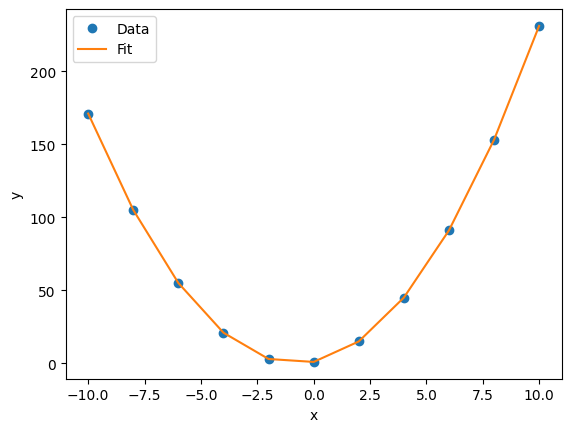

In [ ]:
# Import the packages we need
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Generate sample data to fit, based on known quadratic parameters
xdata = np.arange(-10,11,2)
ydata = 2*xdata**2 + 3*xdata + 1

# Define a quadratic fit function, for y = a*x**2 + b*x + c
def func(x,a,b,c):
  return a*x**2 + b*x + c



# Perform the curve fit and find errors on fitted parameters
popt,pcov = curve_fit(func,xdata,ydata)
perr = np.sqrt(np.diag(pcov))




# Report the values of the fitted parameters and their errors
print('m =', round(popt[0],3), '+/-', round(perr[0],3))
print('c =', round(popt[1],3), '+/-', round(perr[1],3))



# Make a plot of the original data and the fitted curve
plt.plot(xdata,ydata,'o',label='Data')
plt.plot(xdata,func(xdata,*popt),'-',label='Fit')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

#Fitting Real Measurements: Cambridge Climate Data

Now you have successfully used `curve_fit()`, we will apply the same curve fitting method to some real experimental data.

The file `cambridge.dat` (available on the course Moodle site) contains climate data for Cambridge between 1961 and 2010. Similarly to the files we used last week, the file contains a number of header lines, followed by rows of data. Each row contains data for a given month. The information given in each row is, in order, the year, month, maximum temperature, minimum temperature, number of days with an air frost (af), total rainfall and total sunshine hours.

We will now fit the temperature data, and use your fit to estimate the rise in the average temperature in Cambridge over the past 50 years.

To do so, the main steps are to:

* Load in the data.

* Combine the years and month data to give a single time variable (using a function like $t = y +(m-1)/12$).

* Calculate the average temperature for each month.

* Plot out the average temperature versus time, and use the plot to help decide on a suitable
fit function.

* Use `curve_fit()` to obtain the optimised parameters for the function to best fit the data.

* Estimate the temperature rise from the fitted parameters.

Usually, the most difficult step is to choose a suitable fit function with appropriate free parameters.
Even before we examine the data we can guess a good function. Each year the average temperature in Cambridge oscillates annually with the seasons, in addition to there being a slow gradual change. We therefore expect a good model for the data would be given by the sum of a straight line and a sinusoidal
oscillation. Using a single time variable, we can write such a function as

$T = a_0 + a_1(t-1961) + a_2 \sin (\frac{2\pi}{\tau}t+\delta)$

where $t$ is the time in years since the start of 1961 and $\tau$ is 1 year (the period of the oscillation). There are four free parameters in this model;
$a_0$, $a_1$ and $a_2$ are the coefficients of the constant, linear and sinusoidal terms, while $\delta$ is chosen to adjust the phase of the oscillation correctly (i.e. that the oscillatory term is a minimum at the right time of the year).

\

**Now, work through the following steps to fit the climate data**, by filling in the relevant sections of the code cells below.

Two code cells are provided, the first for calculations, and the second for plotting your results.  A series of comments have also been provided in the code cells, to help you structure your work:

1. Download `cambridge.dat` from the Moodle site and upload a copy to Colab.  You will find it in the "Resources" section at the bottom of the Session 3 page.  Double click the file in Colab to open it, and check that you understand its contents.

2. Import the file into Python using `genfromtxt()` as described last week. You can omit the `delimiter=` parameter, as NumPy will automatically detect the columns, but remember that you will need to skip the 4 header lines.

3. Create several new variables representing the columns of the imported data that represents (i) years; (ii) months; (iii) maximum monthly temperature; and (iv) minimum monthly temperature.

4. Combine the year and month vectors to give a single time vector.

5. Estimate the average temperature each month by taking the mean of the minimum and maximum temperatures.

6. Plot the average temperature against time **as a series of individual measurement points**. You should see an oscillating function, superposed on top of a gradual variation, although you may need to zoom in on the figure to be able to see the oscillations clearly. Check you agree that the equation above is a good model for the data.

7. Define your fit function and the use `curvefit()` to find the optimised values of $a_0$, $a_1$, $a_2$ and $\delta$.

8. Add your fitted function to the figure **as a continuous line** (your graph should show both the data points and the fitted function).

9. Use the fitted parameters to estimate the average temperature rise over 50 years.

10. Label your figure correctly and add the temperature rise that you calculated to the title.

11. Export your figure as a high resolution PNG file, as described last week.


0.03248064371362551


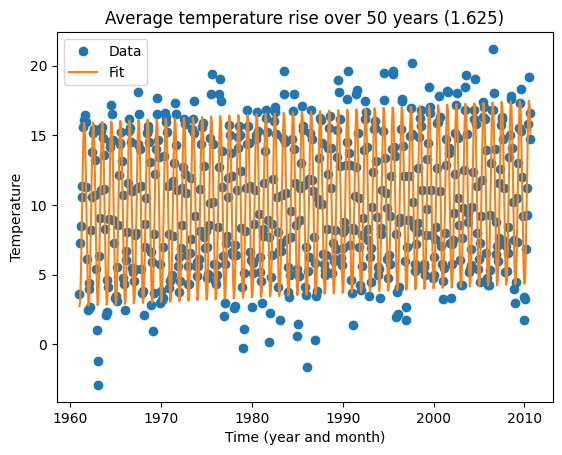

<Figure size 640x480 with 0 Axes>

In [ ]:
# Import the packages we need
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit



# Load in the Cambridge.dat data file
data=np.genfromtxt('cambridge.dat',skip_header=4)


# Separate imported data into columns

year=data[:,0]
month=data[:,1]
maxtemp=data[:,2]
mintemp=data[:,3]


# Combine month and year to give a single time variable

yearMonth= year + (month-1)/12
x=yearMonth

# Estimate the average temperature
averagetemperature=(maxtemp+mintemp)/2
y=averagetemperature

# Define fit function
def func(x,a0,a1,a2,delta):
  T=a0+a1*(x-1961)+a2*np.sin(2*np.pi*x+delta)
  return T
popt,pcov = curve_fit(func,x,y)
perr = np.sqrt(np.diag(pcov))
print(popt[1])

# Apply curve fit


# Plot lines and show the figure
plt.plot(x,y,'o',label='Data')
plt.xlabel('Time (year and month)')
plt.ylabel('Temperature')
plt.title('Average temperature rise over 50 years (1.625)')
plt.plot(x,func(x,*popt),'-',label='Fit')
plt.legend()
plt.show()

plt.savefig('figure1.png',dpi=300)


# Report the values of the fitted parameters and their errors




# Calculate average temperature rise over 50 years



In [ ]:
# Plot data points showing the average temperature against time




# Plot fit




# Export figure




# Show plot on screen





# Submitting Your Third Piece of Work for Credit

This week you simply need to **submit the single high resolution PNG file** that you have just generated. **Instructions are on the course Moodle site**, which explain what you need to do, and how to submit your work.

If you have enough time afterwards, **you should continue to work through the Additional Workbook** for Session 3.
